In [1]:
%matplotlib widget

import cdflib
import numpy as np
import spiceypy as spice
import datetime as dt
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from scipy.interpolate import interp1d
from Ef_utilities import *
from utilities import print_entire

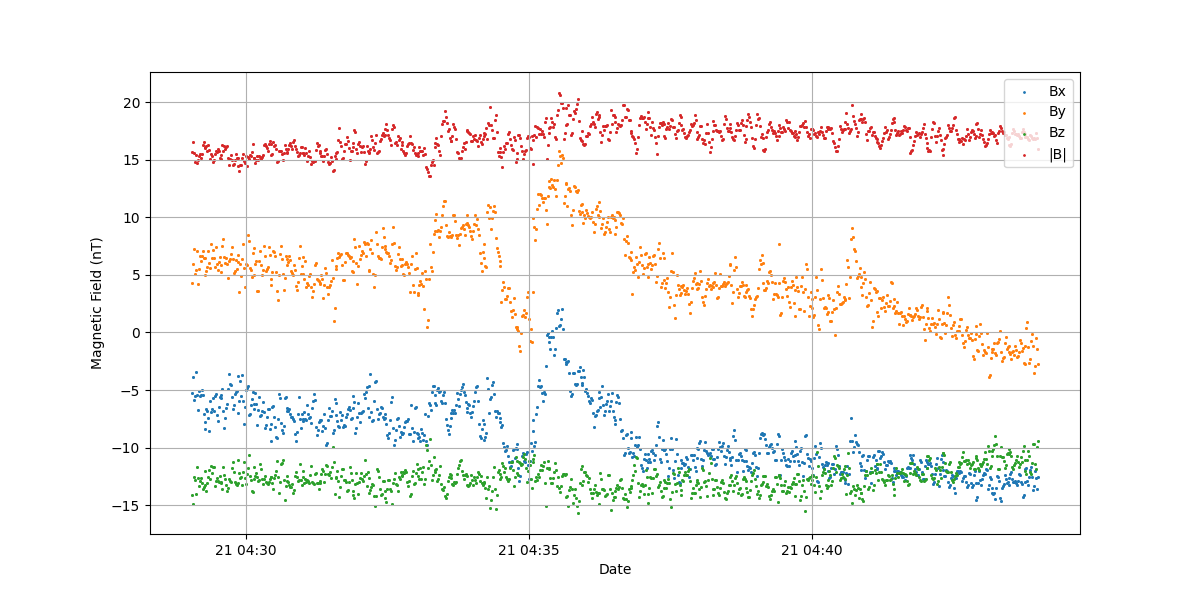

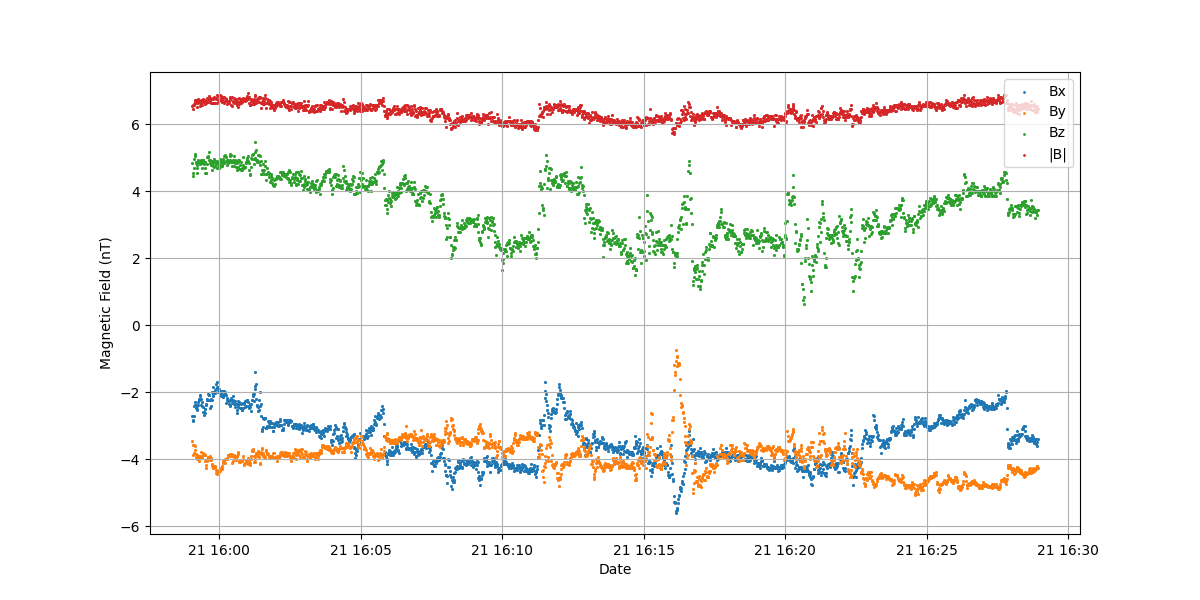

In [2]:
# Get and rotate JMAG data

jmag_cdf = cdflib.CDF('../DATA/jmag_echoed/2024/08/21/JUICE_LU_RPWI-PPTD-LWYRPW79700_20240821T042902_V01.cdf')

NMD = jmag_cdf.varget('NMD')
jmag_epoch = jmag_cdf.varget('Epoch')
jmag_epoch = cdflib.cdfepoch.to_datetime(jmag_epoch)
jmag_epoch = np.array(jmag_epoch, dtype='datetime64[ms]').astype('O')

# Find the index where the separation occurs
epoch_diffs = np.diff(jmag_epoch)
separation_index = np.argmax(epoch_diffs > dt.timedelta(hours=1)) + 1

jmag_epoch1 = jmag_epoch[:separation_index]
jmag_epoch2 = jmag_epoch[separation_index:]

Bx = extract_double_from_columns(NMD, 9, 17)
By = extract_double_from_columns(NMD, 17, 25)
Bz = extract_double_from_columns(NMD, 25, 33)

Bx = np.where(np.abs(Bx) < 1e-9, np.nan, Bx)
By = np.where(np.abs(By) < 1e-9, np.nan, By)
Bz = np.where(np.abs(Bz) < 1e-9, np.nan, Bz)
B_mag = np.sqrt(Bx**2 + By**2 + Bz**2)

# Rotate the magnetic field vectors to the JUICE frame
Bx_rot = R_JMAG[0,0]*Bx + R_JMAG[0,1]*By + R_JMAG[0,2]*Bz
By_rot = R_JMAG[1,0]*Bx + R_JMAG[1,1]*By + R_JMAG[1,2]*Bz
Bz_rot = R_JMAG[2,0]*Bx + R_JMAG[2,1]*By + R_JMAG[2,2]*Bz
Bx = Bx_rot
By = By_rot
Bz = Bz_rot

Bx1 = Bx[:separation_index]
By1 = By[:separation_index]
Bz1 = Bz[:separation_index]
B_mag1 = B_mag[:separation_index]

Bx2 = Bx[separation_index:]
By2 = By[separation_index:]
Bz2 = Bz[separation_index:]
B_mag2 = B_mag[separation_index:]

plt.figure(figsize=(12, 6))
plt.scatter(jmag_epoch1, Bx1, label='Bx', s=1)
plt.scatter(jmag_epoch1, By1, label='By', s=1)
plt.scatter(jmag_epoch1, Bz1, label='Bz', s=1)
plt.scatter(jmag_epoch1, B_mag1, label='|B|', s=1)
plt.legend(loc = 'upper right')
plt.xlabel('Date')
plt.ylabel('Magnetic Field (nT)')
plt.grid()
plt.show()

plt.figure(figsize=(12, 6))
plt.scatter(jmag_epoch2, Bx2, label='Bx', s=1)
plt.scatter(jmag_epoch2, By2, label='By', s=1)
plt.scatter(jmag_epoch2, Bz2, label='Bz', s=1)
plt.scatter(jmag_epoch2, B_mag2, label='|B|', s=1)
plt.legend(loc = 'upper right')
plt.xlabel('Date')
plt.ylabel('Magnetic Field (nT)')
plt.grid()
plt.show()

Distance from JUICE to Sun: 151281095.07343757 km
Distance from WIND to Sun: 149915450.1930079 km
Delta time: -1.191226149614406 hours


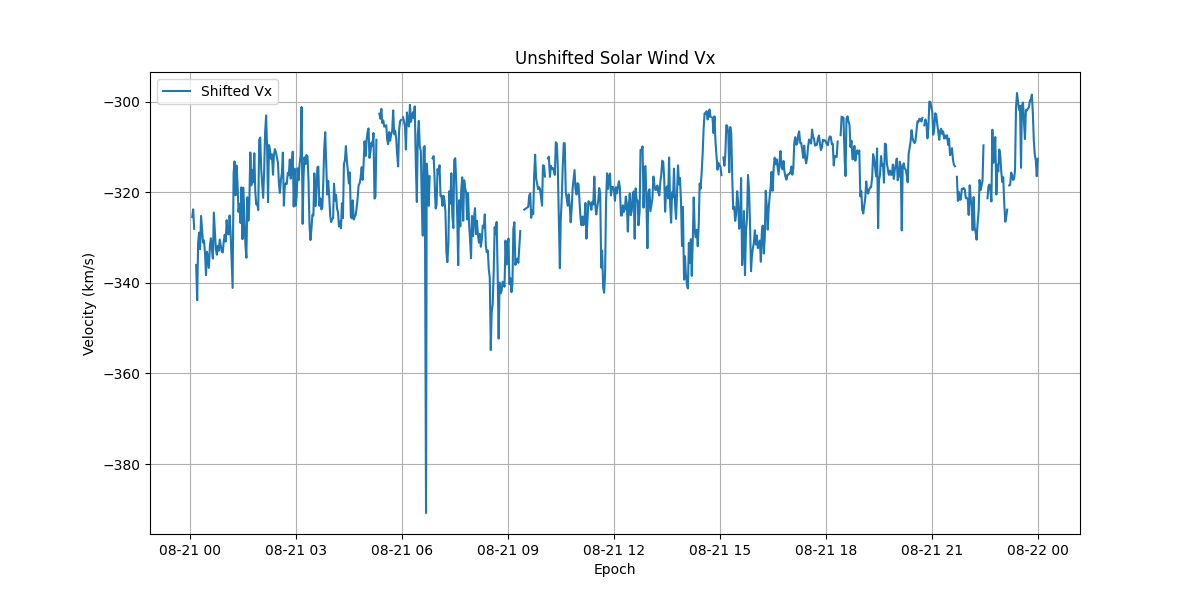

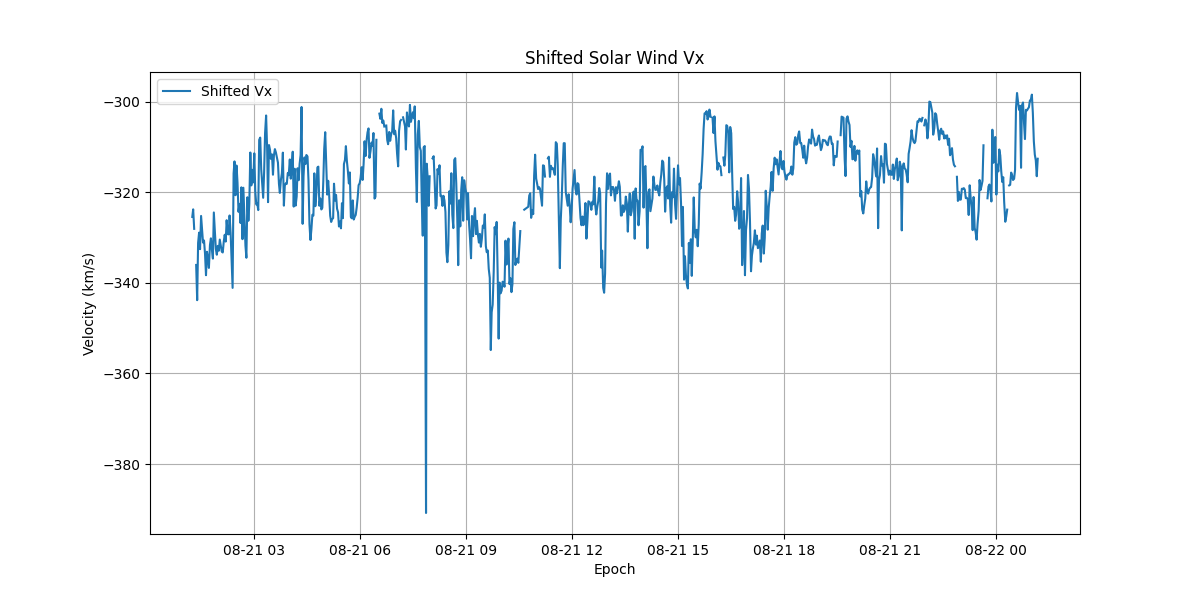

In [3]:
# Get and shift SW data
# We are only taking data from 15:55 to 16:30 because that is when JUICE was in the solar wind

wind_cdf = cdflib.CDF('../DATA/wi_k0s_swe_20240821000335_20240821235902_cdaweb.cdf')

V_GSE = wind_cdf.varget('V_GSE')
WIND_pos_gse = wind_cdf.varget('SC_pos_gse')
wind_epoch = wind_cdf.varget('Epoch')
wind_epoch = cdflib.cdfepoch.to_datetime(wind_epoch)
wind_epoch = np.array(wind_epoch, dtype='datetime64[ms]').astype('O')

V_GSE[V_GSE < -1e5] = np.nan # Remove all of the 0 values from the solar wind data
sw_speed = -np.nanmean(V_GSE[:, 0], axis=0) # Get the average speed of the solar wind in km/s during the considered time period

# Load the necessary SPICE kernels
spice.furnsh("../SPICE/JUICE/kernels/mk/juice_ops.tm")

et = spice.str2et("2024-08-21T16:00:00")

pos_earth_j2000, _ = spice.spkpos("EARTH", et, "J2000", "NONE", "SUN")
distance_earth_sun = np.linalg.norm(pos_earth_j2000)

# Getting WIND's distance to the Sun : in GSE, X axis is Sun-Earth direction, 
# so just need to change the X coordinate to recenter the coordinate system on the Sun
WIND_pos_sun_centered_x = WIND_pos_gse[:, 0] - distance_earth_sun

WIND_distance_sun = np.sqrt(WIND_pos_sun_centered_x**2 + WIND_pos_gse[:, 1]**2 + WIND_pos_gse[:, 2]**2)
avrg_WIND_distance_sun = np.nanmean(WIND_distance_sun)

pos_juice_j2000, _ = spice.spkpos("JUICE", et, "J2000", "NONE", "SUN")
distance_juice_sun = np.linalg.norm(pos_juice_j2000)

print(f"Distance from JUICE to Sun: {distance_juice_sun} km")
print(f"Distance from WIND to Sun: {avrg_WIND_distance_sun} km")

delta_distance = avrg_WIND_distance_sun - distance_juice_sun

delta_time = delta_distance / sw_speed
print(f"Delta time: {delta_time/(60*60)} hours")

# Plot before shifting
plt.figure(figsize=(12, 6))
plt.plot(wind_epoch, V_GSE[:, 0], label='Shifted Vx')
plt.title('Unshifted Solar Wind Vx')
plt.xlabel('Epoch')
plt.ylabel('Velocity (km/s)')
plt.legend()
plt.grid()
plt.show()

# Shift the solar wind data to delta_time seconds earlier this way the solar wind data is plotted on the time it reaches JUICE
wind_epoch_shifted = wind_epoch - dt.timedelta(seconds=delta_time)
plt.figure(figsize=(12, 6))
plt.plot(wind_epoch_shifted, V_GSE[:, 0], label='Shifted Vx')
plt.title('Shifted Solar Wind Vx')
plt.xlabel('Epoch')
plt.ylabel('Velocity (km/s)')
plt.legend()
plt.grid()
plt.show()

spice.kclear()  # Clear SPICE kernels after use

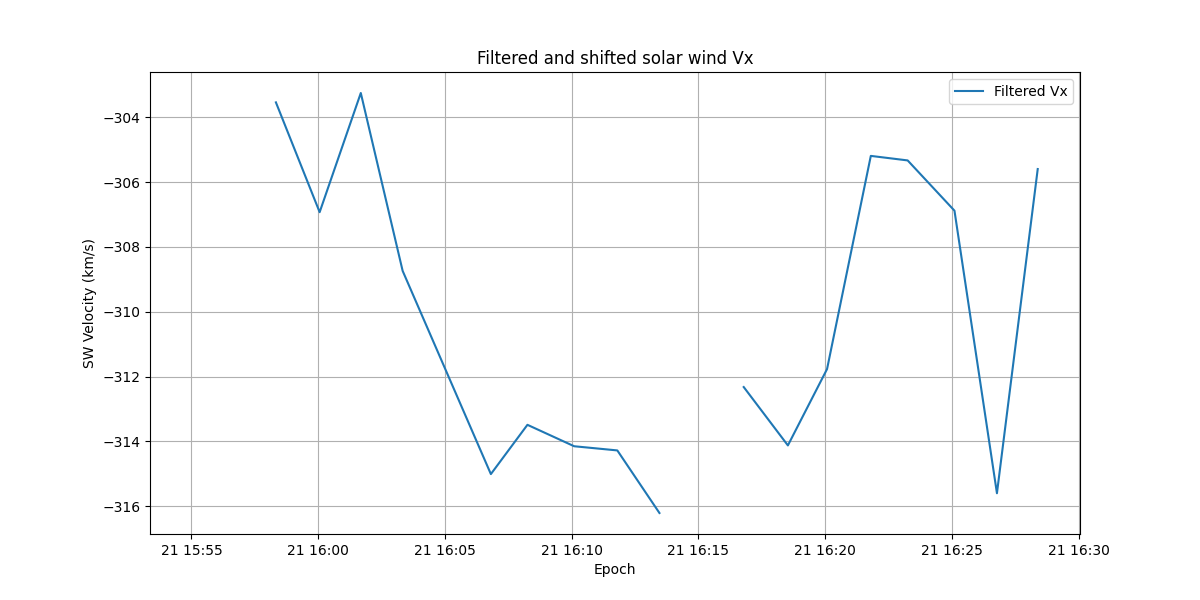

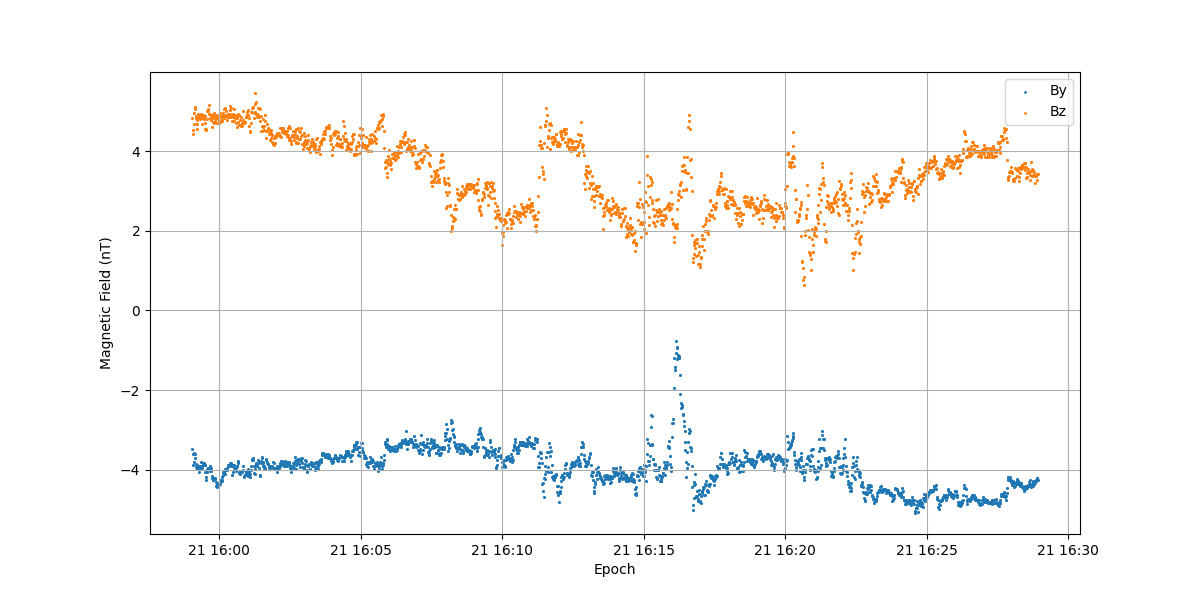

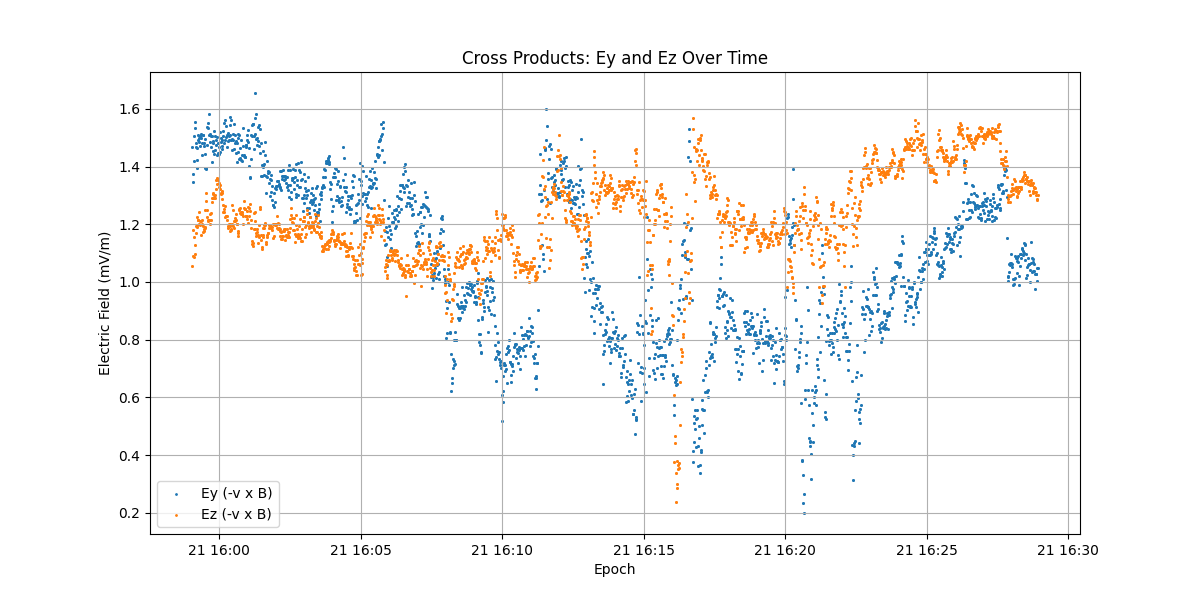

In [4]:
# Calculate - v cross B

# X axis for JUICE points away from HGA antenna, so AWAY from the Sun, so SW speed needs to be positive

# Start and end times for the plot of solar wind data
start_time = dt.datetime(2024, 8, 21, 15, 55, 0)
end_time = dt.datetime(2024, 8, 21, 16, 30, 0)

cross_products = np.zeros((len(jmag_epoch2), 3))

# Calculate the cross product of the solar wind velocity and the magnetic field
# For each time step in the JMAG data, we find the closest time step in the shifted solar wind data
for i in range(len(jmag_epoch2)):
    time_diffs = np.abs(wind_epoch_shifted - jmag_epoch2[i])
    sorted_indices = np.argsort(time_diffs)
    
    sw_vx = np.nan
    for idx in sorted_indices:
        if not np.isnan(V_GSE[idx, 0]):
            sw_vx = V_GSE[idx, 0]
            break
    sw_vx = -sw_vx  # In JUICE frame, the velocity is negative
    
    cross_products[i] = [0, -float(-Bz2[i] * sw_vx * 1e-6), -float(By2[i] * sw_vx * 1e-6)]

ExvCB = cross_products[:, 0]
EyvCB = cross_products[:, 1]
EzvCB = cross_products[:, 2]

# Filter the solar wind data for the specified time range
filtered_indices = [i for i, t in enumerate(wind_epoch_shifted) if start_time <= t <= end_time]
wind_epoch_filtered = wind_epoch_shifted[filtered_indices]
V_GSE_filtered = V_GSE[filtered_indices, 0]

# Plot the filtered solar wind data
plt.figure(figsize=(12, 6))
plt.plot(wind_epoch_filtered, V_GSE_filtered, label='Filtered Vx')
plt.title('Filtered and shifted solar wind Vx')
plt.xlabel('Epoch')
plt.ylabel('SW Velocity (km/s)')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(12, 6))
plt.scatter(jmag_epoch2, By2, label='By', s = 1)
plt.scatter(jmag_epoch2, Bz2, label='Bz', s = 1)
plt.xlabel('Epoch')
plt.ylabel('Magnetic Field (nT)')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(12, 6))
plt.scatter(jmag_epoch2, EyvCB*1e3, label='Ey (-v x B)', s=1)
plt.scatter(jmag_epoch2, EzvCB*1e3, label='Ez (-v x B)', s=1)
plt.title('Cross Products: Ey and Ez Over Time')
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.legend()
plt.grid()
plt.show()

C:\Users\lesco\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\ipympl\backend_nbagg.py:335: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  self.figure.savefig(buf, format='png', dpi='figure')


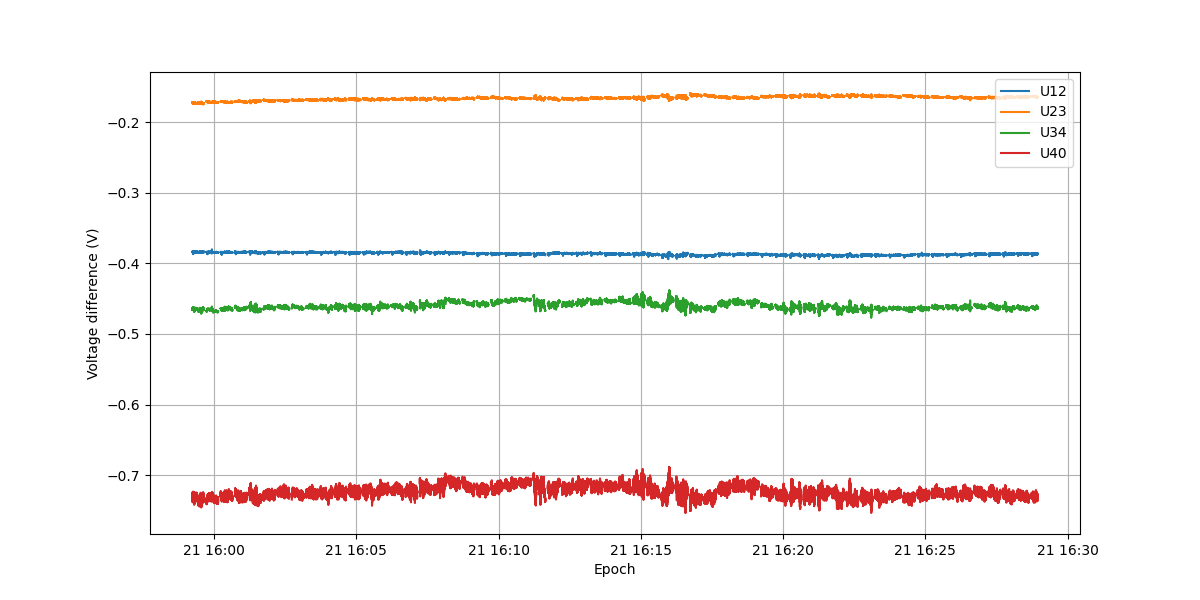

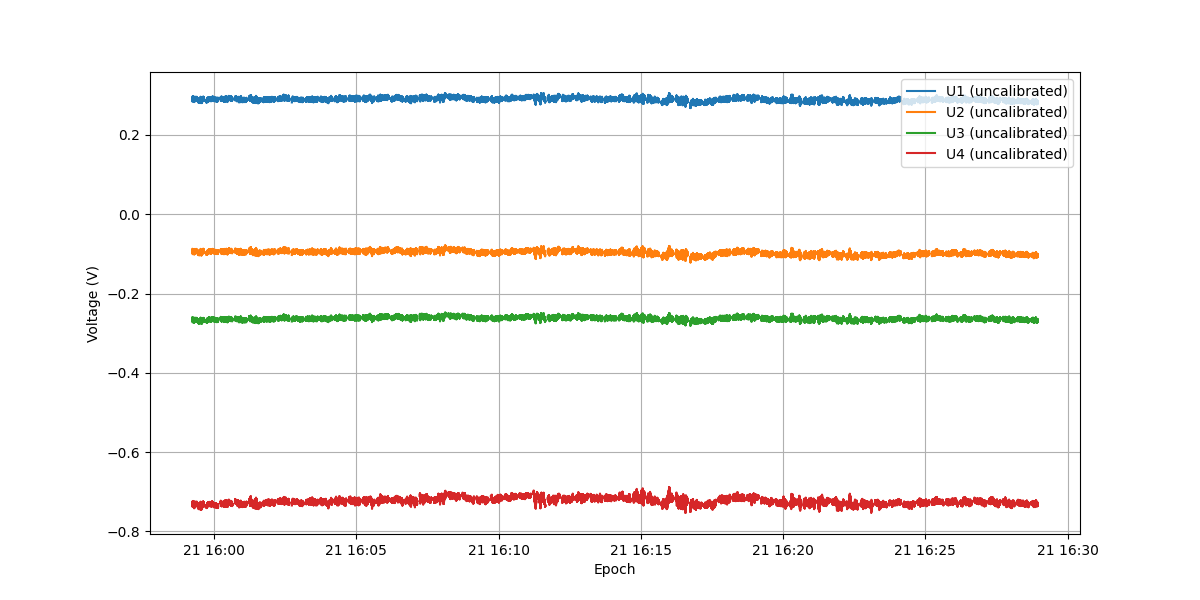

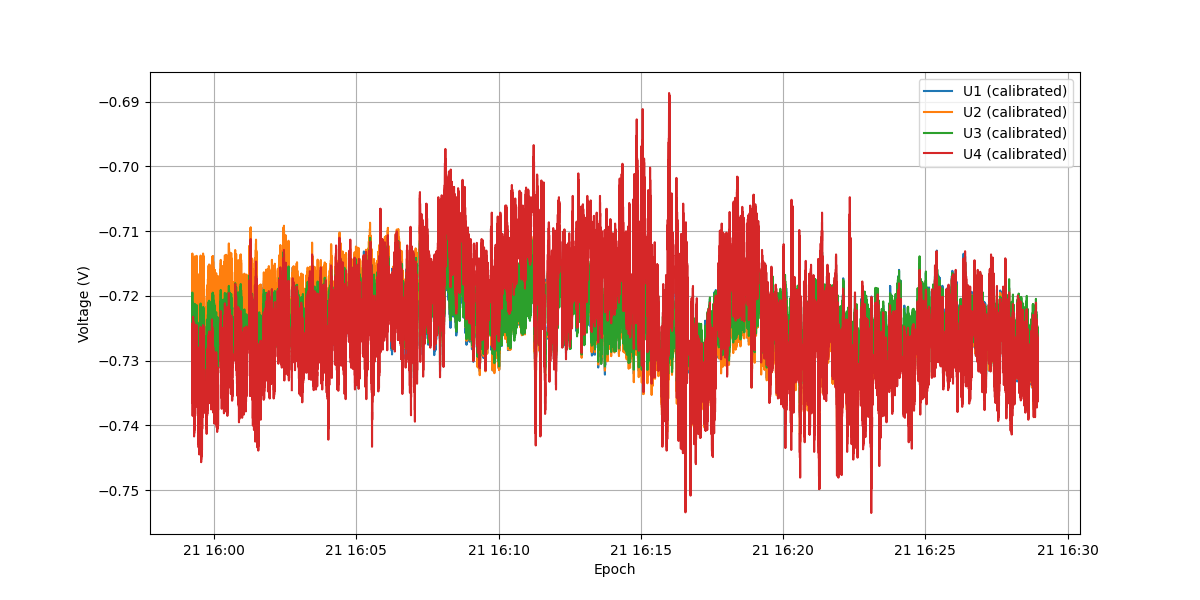

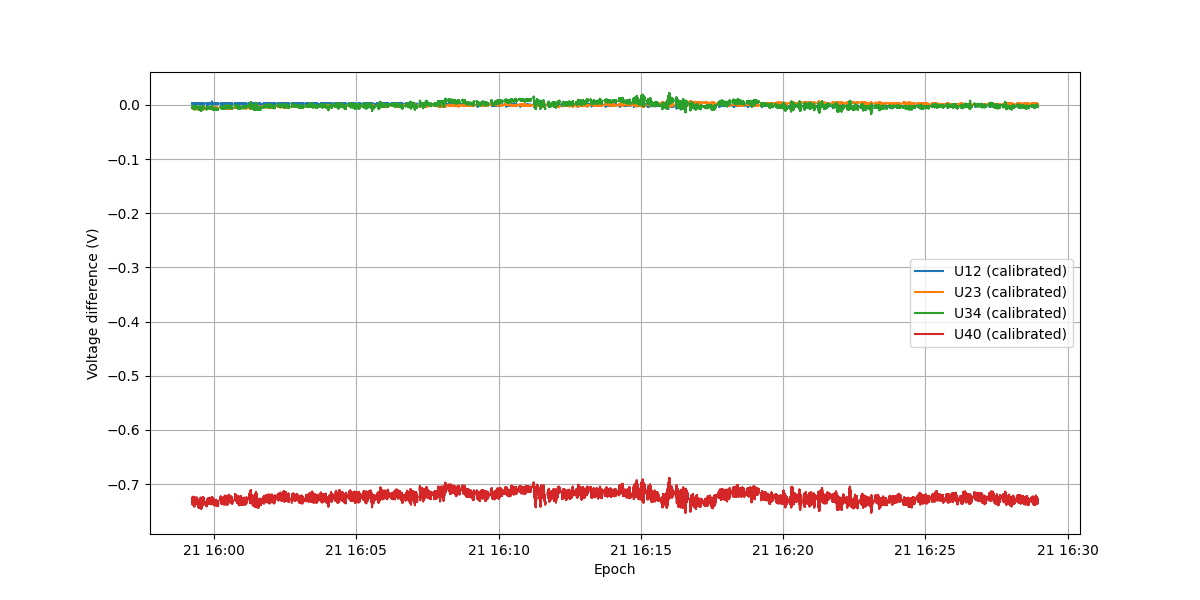

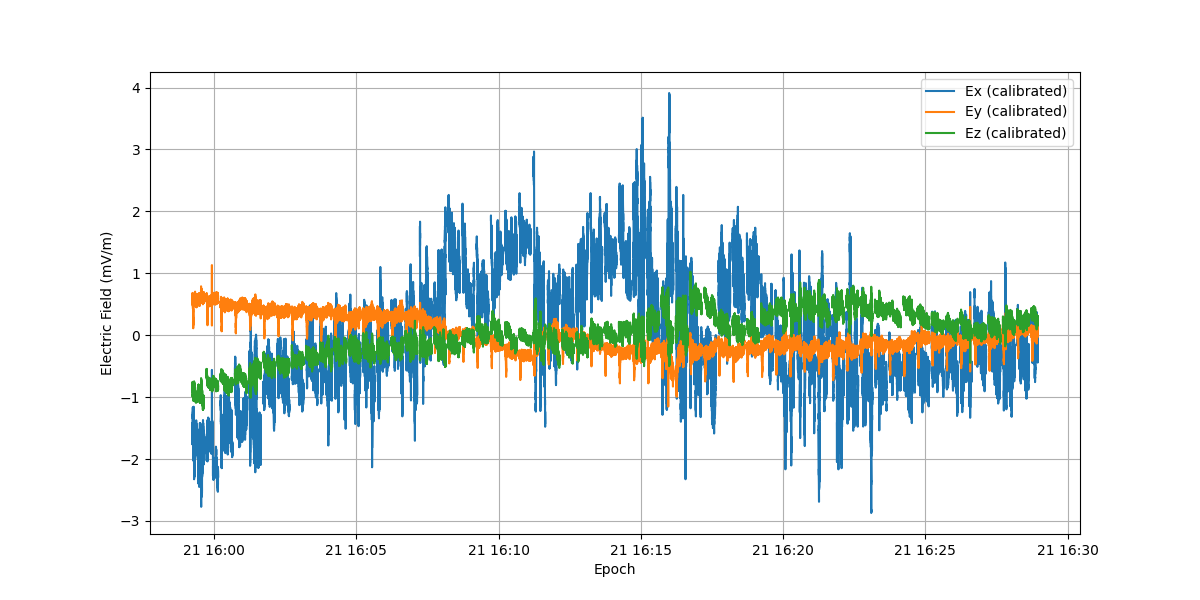

In [5]:
# Get E field

avg_value_correction = True
# Start and end dates for filtering
start_date = dt.datetime(2024, 8, 21, 15, 55, 0)
end_date = dt.datetime(2024, 8, 21, 16, 30, 0)

lp_cdf1 = cdflib.CDF('../DATA/JUICE_L1a_RPWI-LP-SID1_RICH_DE763_SNAP_20240821T043653_V03.cdf')
lp_cdf2 = cdflib.CDF('../DATA/JUICE_L1a_RPWI-LP-SID1_RICH_DE763_SNAP_20240821T161043_V03.cdf')

TM1_1 = lp_cdf1.varget('LP_DATA')[:, 0]
TM2_1 = lp_cdf1.varget('LP_DATA')[:, 1]
TM3_1 = lp_cdf1.varget('LP_DATA')[:, 2]
TM4_1 = lp_cdf1.varget('LP_DATA')[:, 3]

U12_1 = TM1_1 * TM2diff[0]
U23_1 = TM2_1 * TM2diff[1]
U34_1 = TM3_1 * TM2diff[2]
U40_1 = TM4_1 * TM2diff[3]

TM1_2 = lp_cdf2.varget('LP_DATA')[:, 0]
TM2_2 = lp_cdf2.varget('LP_DATA')[:, 1]
TM3_2 = lp_cdf2.varget('LP_DATA')[:, 2]
TM4_2 = lp_cdf2.varget('LP_DATA')[:, 3]

U12_2 = TM1_2 * TM2diff[0]
U23_2 = TM2_2 * TM2diff[1]
U34_2 = TM3_2 * TM2diff[2]
U40_2 = TM4_2 * TM2diff[3]

lp_epoch1 = lp_cdf1.varget('Epoch')
lp_epoch1 = cdflib.cdfepoch.to_datetime(lp_epoch1)
lp_epoch1 = np.array(lp_epoch1, dtype='datetime64[ms]').astype('O')

lp_epoch2 = lp_cdf2.varget('Epoch')
lp_epoch2 = cdflib.cdfepoch.to_datetime(lp_epoch2)
lp_epoch2 = np.array(lp_epoch2, dtype='datetime64[ms]').astype('O')

# Concatenate the data from both CDF files
lp_epoch = np.concatenate((lp_epoch1, lp_epoch2))
U12 = np.concatenate((U12_1, U12_2))
U23 = np.concatenate((U23_1, U23_2))
U34 = np.concatenate((U34_1, U34_2))
U40 = np.concatenate((U40_1, U40_2))

# Filter the TM lists and epoch list
filtered_indices = [i for i, t in enumerate(lp_epoch) if start_date <= t <= end_date]
lp_epoch = lp_epoch[filtered_indices]
U12 = U12[filtered_indices]
U23 = U23[filtered_indices]
U34 = U34[filtered_indices]
U40 = U40[filtered_indices]

U12 = filter_out_start_config_noise(U12, lp_epoch)
U23 = filter_out_start_config_noise(U23, lp_epoch)
U34 = filter_out_start_config_noise(U34, lp_epoch)
U40 = filter_out_start_config_noise(U40, lp_epoch)

plt.figure(figsize=(12, 6))
plt.plot(lp_epoch, U12, label='U12')
plt.plot(lp_epoch, U23, label='U23')
plt.plot(lp_epoch, U34, label='U34')
plt.plot(lp_epoch, U40, label='U40')
plt.xlabel('Epoch')
plt.ylabel('Voltage difference (V)')
plt.legend()
plt.grid()
plt.show()

U1, U2, U3, U4 = multiply_lists_by_44matrix(U12, U23, U34, U40, diff2volt)

plt.figure(figsize=(12, 6))
plt.plot(lp_epoch, U1, label='U1 (uncalibrated)')
plt.plot(lp_epoch, U2, label='U2 (uncalibrated)')
plt.plot(lp_epoch, U3, label='U3 (uncalibrated)')
plt.plot(lp_epoch, U4, label='U4 (uncalibrated)')
plt.xlabel('Epoch')
plt.ylabel('Voltage (V)')
plt.legend()
plt.grid()
plt.show()

if avg_value_correction:
    mean_diff_U1 = np.nanmean(np.array(U4) - np.array(U1))
    mean_diff_U2 = np.nanmean(np.array(U4) - np.array(U2))
    mean_diff_U3 = np.nanmean(np.array(U4) - np.array(U3))

    U1 = np.array([float(u) + float(mean_diff_U1) for u in U1])
    U2 = np.array([float(u) + float(mean_diff_U2) for u in U2])
    U3 = np.array([float(u) + float(mean_diff_U3) for u in U3])

plt.figure(figsize=(12, 6))
plt.plot(lp_epoch, U1, label='U1 (calibrated)')
plt.plot(lp_epoch, U2, label='U2 (calibrated)')
plt.plot(lp_epoch, U3, label='U3 (calibrated)')
plt.plot(lp_epoch, U4, label='U4 (calibrated)')
plt.xlabel('Epoch')
plt.ylabel('Voltage (V)')
plt.legend()
plt.grid()
plt.show()

U12, U23, U34, U40 = multiply_lists_by_44matrix(U1, U2, U3, U4, volt2diff)

plt.figure(figsize=(12, 6))
plt.plot(lp_epoch, U12, label='U12 (calibrated)')
plt.plot(lp_epoch, U23, label='U23 (calibrated)')
plt.plot(lp_epoch, U34, label='U34 (calibrated)')
plt.plot(lp_epoch, U40, label='U40 (calibrated)')
plt.xlabel('Epoch')
plt.ylabel('Voltage difference (V)')
plt.legend()
plt.grid()
plt.show()

Ex, Ey, Ez = multiply_lists_by_33matrix(U12, U23, U34, volt2E)

plt.figure(figsize=(12, 6))
plt.plot(lp_epoch, Ex*1e3, label='Ex (calibrated)')
plt.plot(lp_epoch, Ey*1e3, label='Ey (calibrated)')
plt.plot(lp_epoch, Ez*1e3, label='Ez (calibrated)')
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.legend()
plt.grid()
plt.show()

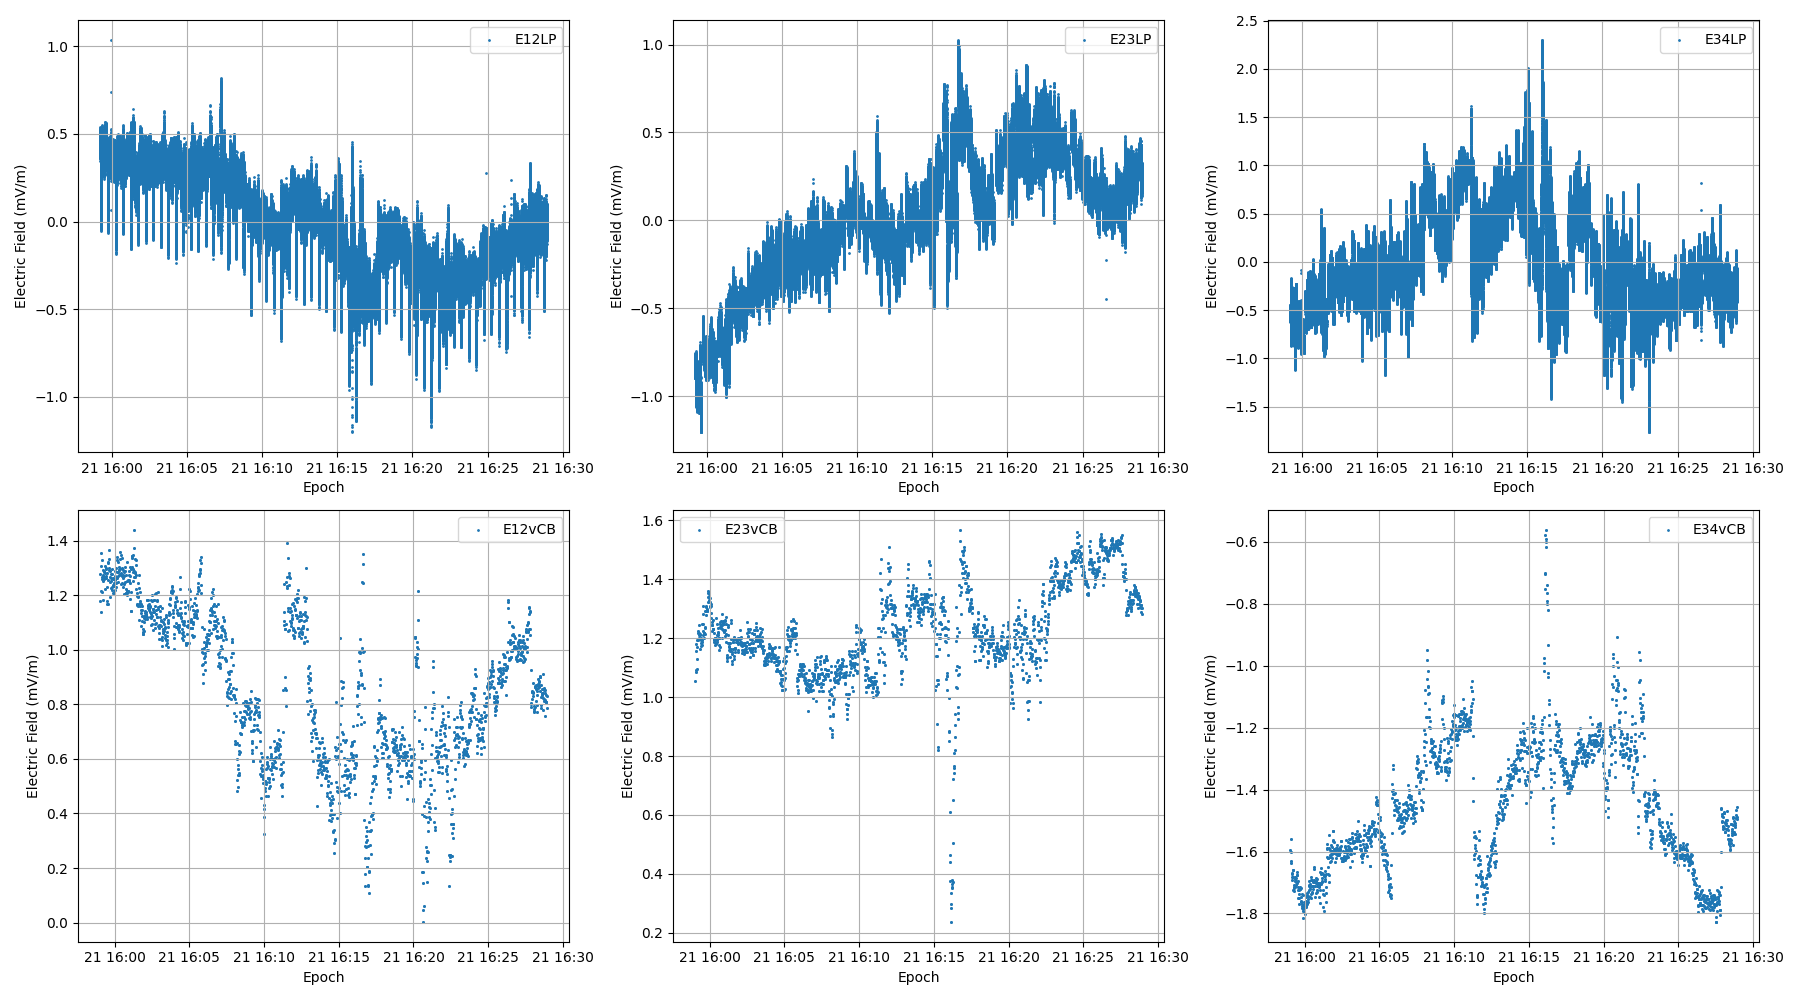

In [11]:
# Trying to look at data in the LP probe frame

E12vCB, E23vCB, E34vCB = multiply_lists_by_33matrix(ExvCB, EyvCB, EzvCB, E2volt)
E12vCB = E12vCB / probe_dist[0]
E23vCB = E23vCB / probe_dist[1]
E34vCB = E34vCB / probe_dist[2]

E12LP, E23LP, E34LP = multiply_lists_by_33matrix(Ex, Ey, Ez, E2volt)
E12LP = E12LP / probe_dist[0]
E23LP = E23LP / probe_dist[1]
E34LP = E34LP / probe_dist[2]

plt.figure(figsize=(18, 10))

plt.subplot(2, 3, 1)
plt.scatter(lp_epoch, E12LP*1e3, label='E12LP', s=1)
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.legend()
plt.grid()

plt.subplot(2, 3, 2)
plt.scatter(lp_epoch, E23LP*1e3, label='E23LP', s=1)
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.legend()
plt.grid()

plt.subplot(2, 3, 3)
plt.scatter(lp_epoch, E34LP*1e3, label='E34LP', s=1)
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.legend()
plt.grid()

plt.subplot(2, 3, 4)
plt.scatter(jmag_epoch2, E12vCB*1e3, label='E12vCB', s=1)
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.legend()
plt.grid()

plt.subplot(2, 3, 5)
plt.scatter(jmag_epoch2, E23vCB*1e3, label='E23vCB', s=1)
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.legend()
plt.grid()

plt.subplot(2, 3, 6)
plt.scatter(jmag_epoch2, E34vCB*1e3, label='E34vCB', s=1)
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

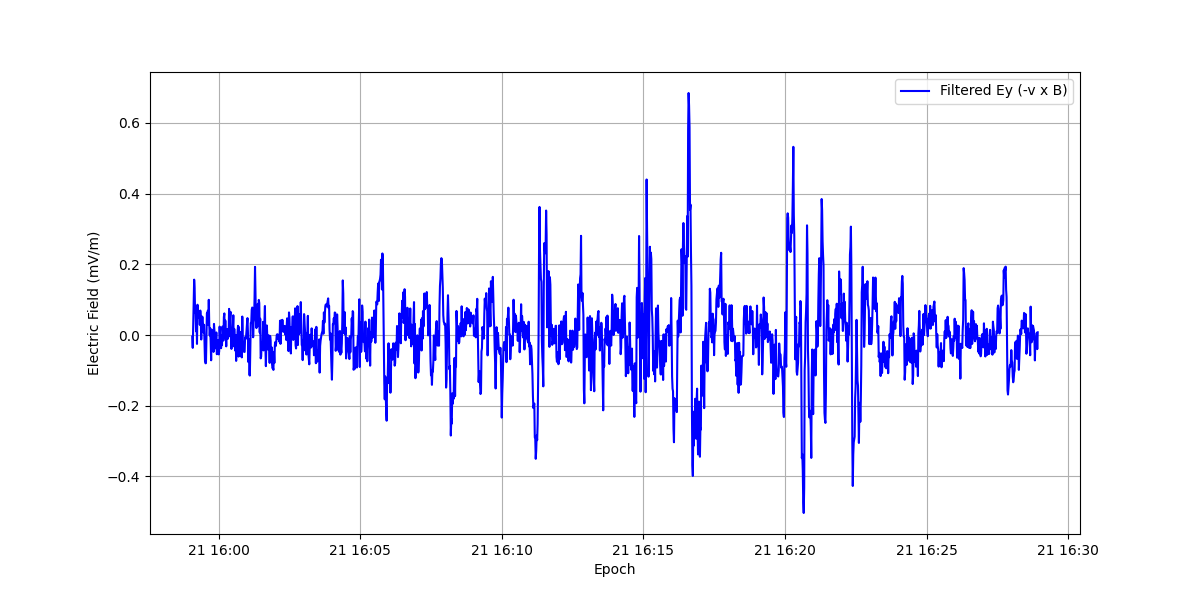

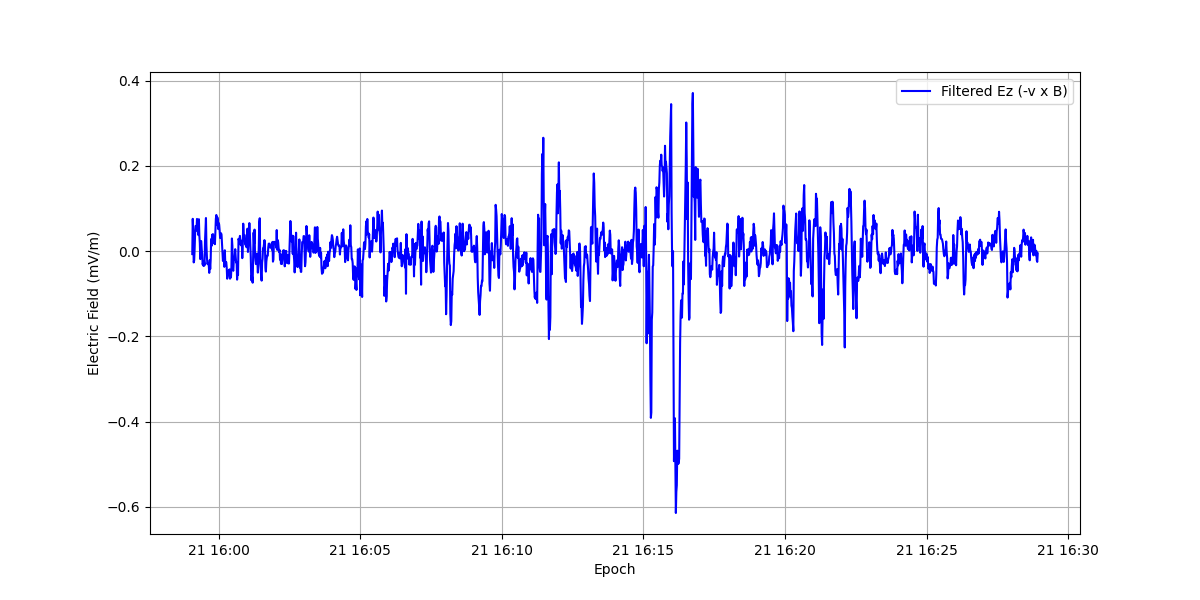

In [102]:
# Trying a high pass filter on the v cross B data

cutoff = 0.01 # Cutoff frequency in Hz
order = 2
sampling_rate = 1 # Hz

# Filter out NaN values from EyvCB and EzvCB
mask = np.isfinite(EyvCB) & np.isfinite(EzvCB)
EyvCB_mask = EyvCB[mask]
EzvCB_mask = EzvCB[mask]
jmag_epoch2_mask = jmag_epoch2[mask]

# Create a uniformly spaced time array starting from jmag_epoch[0]
start_time = jmag_epoch2_mask[0]
end_time = jmag_epoch2_mask[-1]
uniform_times_jmag = np.arange(
    start_time, end_time + np.timedelta64(1, 's'),
    np.timedelta64(1, 's')
).astype('datetime64[ms]').astype('O')

# Interpolate EyvCB and EzvCB onto the uniform time grid
jmag_seconds = np.array([(t - start_time).total_seconds() for t in jmag_epoch2_mask])
uniform_seconds = np.array([(t - start_time).total_seconds() for t in uniform_times_jmag])

interp_Ey = interp1d(jmag_seconds, EyvCB_mask, kind='linear', bounds_error=False, fill_value='extrapolate')
interp_Ez = interp1d(jmag_seconds, EzvCB_mask, kind='linear', bounds_error=False, fill_value='extrapolate')

EyvCB_uniform = interp_Ey(uniform_seconds)[1:]
EzvCB_uniform = interp_Ez(uniform_seconds)[1:]
uniform_times_jmag = uniform_times_jmag[1:]

# Filter the Ey and Ez data
EyvCB_filtered = highpass_filter(EyvCB_uniform, cutoff, sampling_rate, order)
EzvCB_filtered = highpass_filter(EzvCB_uniform, cutoff, sampling_rate, order)

# Plot the filtered Ey and Ez data
plt.figure(figsize=(12, 6))
plt.plot(uniform_times_jmag, EyvCB_filtered*1e3, label='Filtered Ey (-v x B)', color = 'blue')
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(uniform_times_jmag, EzvCB_filtered*1e3, label='Filtered Ez (-v x B)', color = 'blue')
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.legend()
plt.grid()
plt.show()

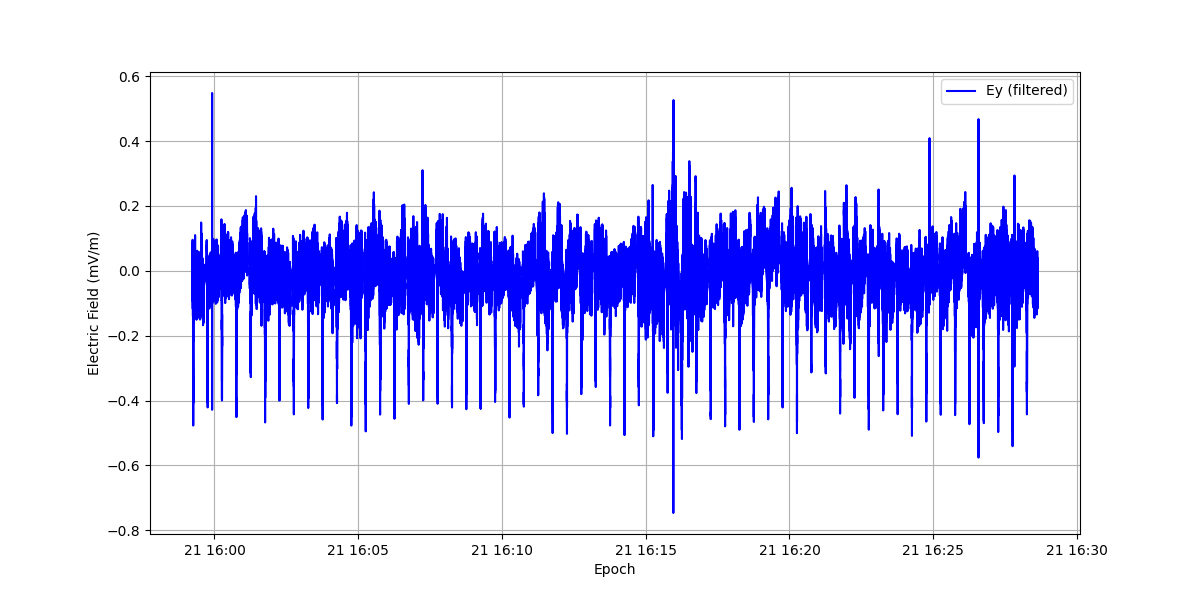

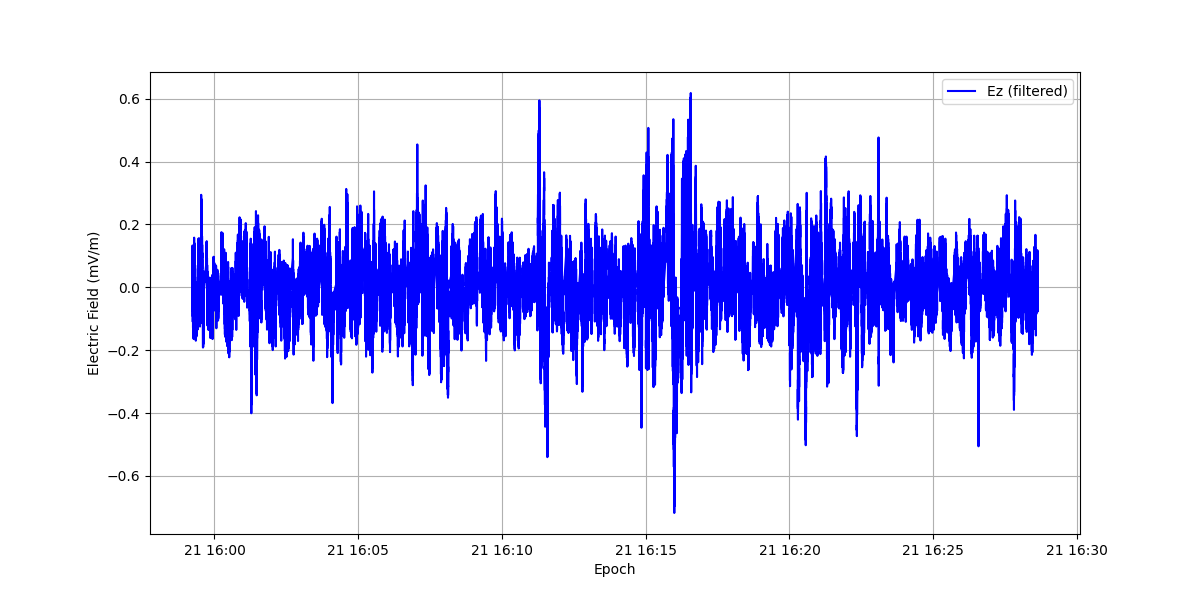

In [103]:
# Trying a high-pass filter on the LP E-field data

cutoff = 0.01  # Desired cutoff frequency of the filter, Hz
order = 2

# Separate the data into different sections based on time gaps larger than 1 second
sections = []
current_section = [0]  # Start with the first index

for i in range(1, len(lp_epoch)):
    time_diff = (lp_epoch[i] - lp_epoch[i - 1]).total_seconds()
    if time_diff > 0.1:
        sections.append(current_section)
        current_section = [i]
    else:
        current_section.append(i)

# Create separate lists for Ex, Ey, Ez based on the sections
Ex_sections = [Ex[section] for section in sections]
Ey_sections = [Ey[section] for section in sections]
Ez_sections = [Ez[section] for section in sections]
lp_epoch_sections = [lp_epoch[section] for section in sections]

# Resample each section to have a constant sampling rate (1 ms steps)
resampled_Ex_sections = []
resampled_Ey_sections = []
resampled_Ez_sections = []
resampled_lp_epoch_sections = []

for epoch_section, Ex_section, Ey_section, Ez_section in zip(lp_epoch_sections, Ex_sections, Ey_sections, Ez_sections):
    # Create a uniformly spaced time array (1 ms steps)
    start_time = epoch_section[0]
    end_time = epoch_section[-1]
    num_points = int((end_time - start_time).total_seconds() * 1000) + 1
    uniform_times = np.array([start_time + dt.timedelta(milliseconds=i) for i in range(num_points)], dtype='O')

    # Convert times to seconds since start for interpolation
    epoch_seconds = np.array([(t - start_time).total_seconds() for t in epoch_section])
    uniform_seconds = np.array([(t - start_time).total_seconds() for t in uniform_times])

    # Interpolate Ex, Ey, Ez onto the uniform time grid
    interp_Ex = interp1d(epoch_seconds, Ex_section, kind='linear', bounds_error=False, fill_value='extrapolate')
    interp_Ey = interp1d(epoch_seconds, Ey_section, kind='linear', bounds_error=False, fill_value='extrapolate')
    interp_Ez = interp1d(epoch_seconds, Ez_section, kind='linear', bounds_error=False, fill_value='extrapolate')

    Ex_uniform = interp_Ex(uniform_seconds)
    Ey_uniform = interp_Ey(uniform_seconds)
    Ez_uniform = interp_Ez(uniform_seconds)

    resampled_Ex_sections.append(Ex_uniform)
    resampled_Ey_sections.append(Ey_uniform)
    resampled_Ez_sections.append(Ez_uniform)
    resampled_lp_epoch_sections.append(uniform_times)

# Replace the original sections with the resampled ones
Ex_sections = resampled_Ex_sections
Ey_sections = resampled_Ey_sections
Ez_sections = resampled_Ez_sections
lp_epoch_sections = resampled_lp_epoch_sections

sampling_rate = 1000  # Hz (since we now have 1 ms steps)

# Apply the high-pass filter to each section individually and then concatenate the results
Ex_filtered_sections = []
Ey_filtered_sections = []
Ez_filtered_sections = []
lp_epoch_filtered_sections = []

for Ex_section, Ey_section, Ez_section, lp_epoch_section in zip(Ex_sections, Ey_sections, Ez_sections, lp_epoch_sections):
    valid_indices = ~np.isnan(Ex_section) & ~np.isnan(Ey_section) & ~np.isnan(Ez_section)
    Ex_filtered = highpass_filter(Ex_section[valid_indices], cutoff, sampling_rate, order)
    Ey_filtered = highpass_filter(Ey_section[valid_indices], cutoff, sampling_rate, order)
    Ez_filtered = highpass_filter(Ez_section[valid_indices], cutoff, sampling_rate, order)
    lp_epoch_filtered = lp_epoch_section[valid_indices]
    
    Ex_filtered_sections.append(Ex_filtered)
    Ey_filtered_sections.append(Ey_filtered)
    Ez_filtered_sections.append(Ez_filtered)
    lp_epoch_filtered_sections.append(lp_epoch_filtered)

# Concatenate the filtered sections back into a single array
Ex_filtered_full = np.concatenate(Ex_filtered_sections)
Ey_filtered_full = np.concatenate(Ey_filtered_sections)
Ez_filtered_full = np.concatenate(Ez_filtered_sections)
lp_epoch_filtered_full = np.concatenate(lp_epoch_filtered_sections)

plt.figure(figsize=(12, 6))
plt.plot(lp_epoch_filtered_full, Ey_filtered_full*1e3, label='Ey (filtered)', color = 'blue')
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(lp_epoch_filtered_full, Ez_filtered_full*1e3, label='Ez (filtered)', color = 'blue')
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.legend()
plt.grid()
plt.show()

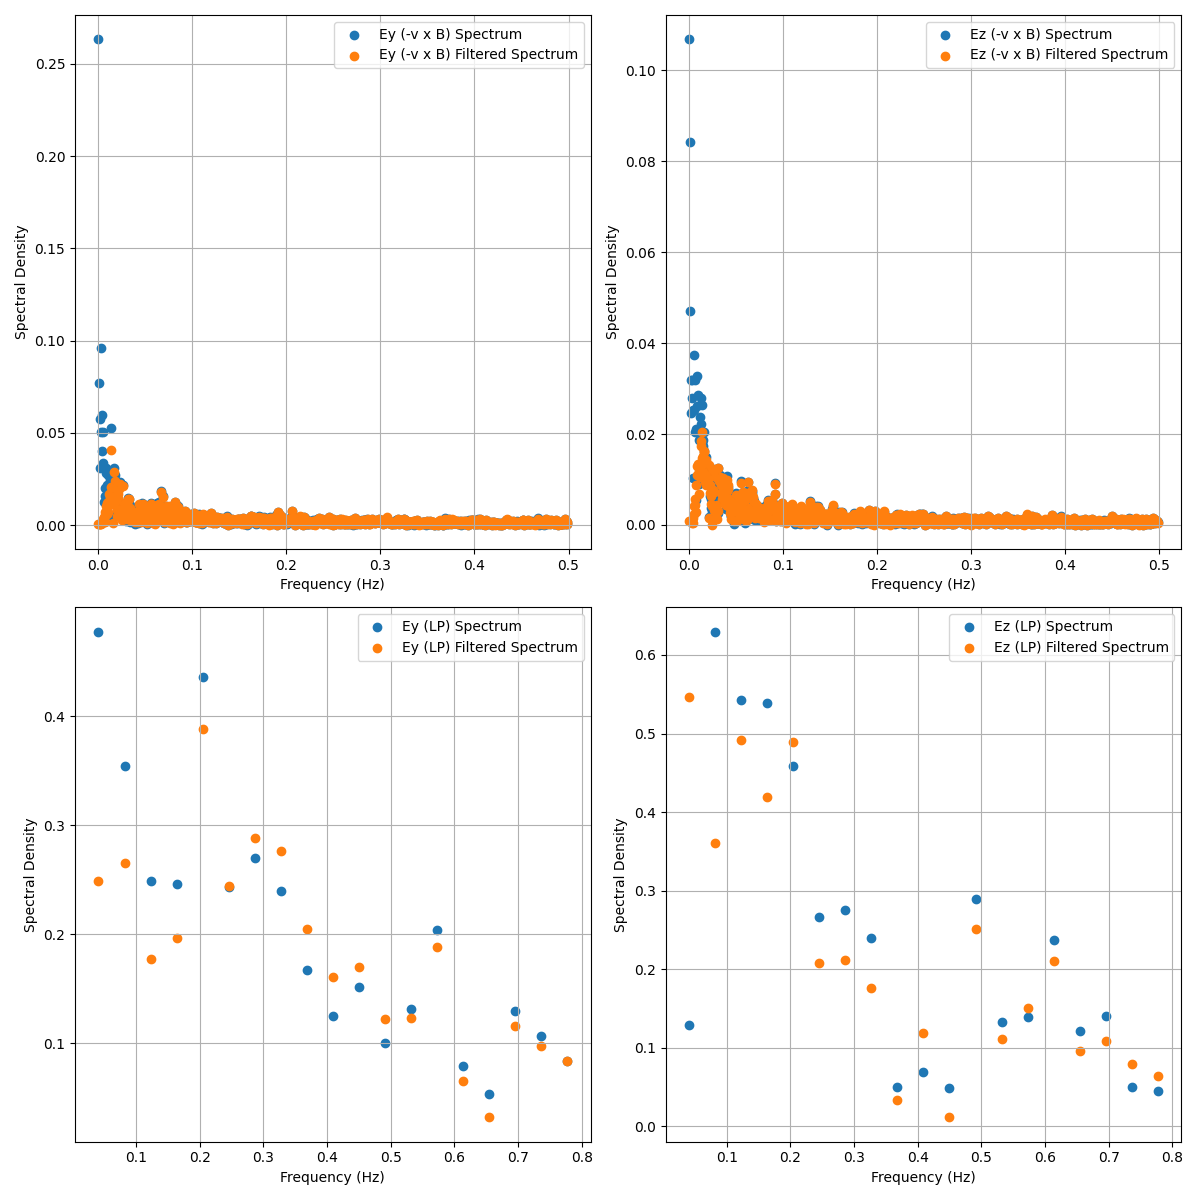

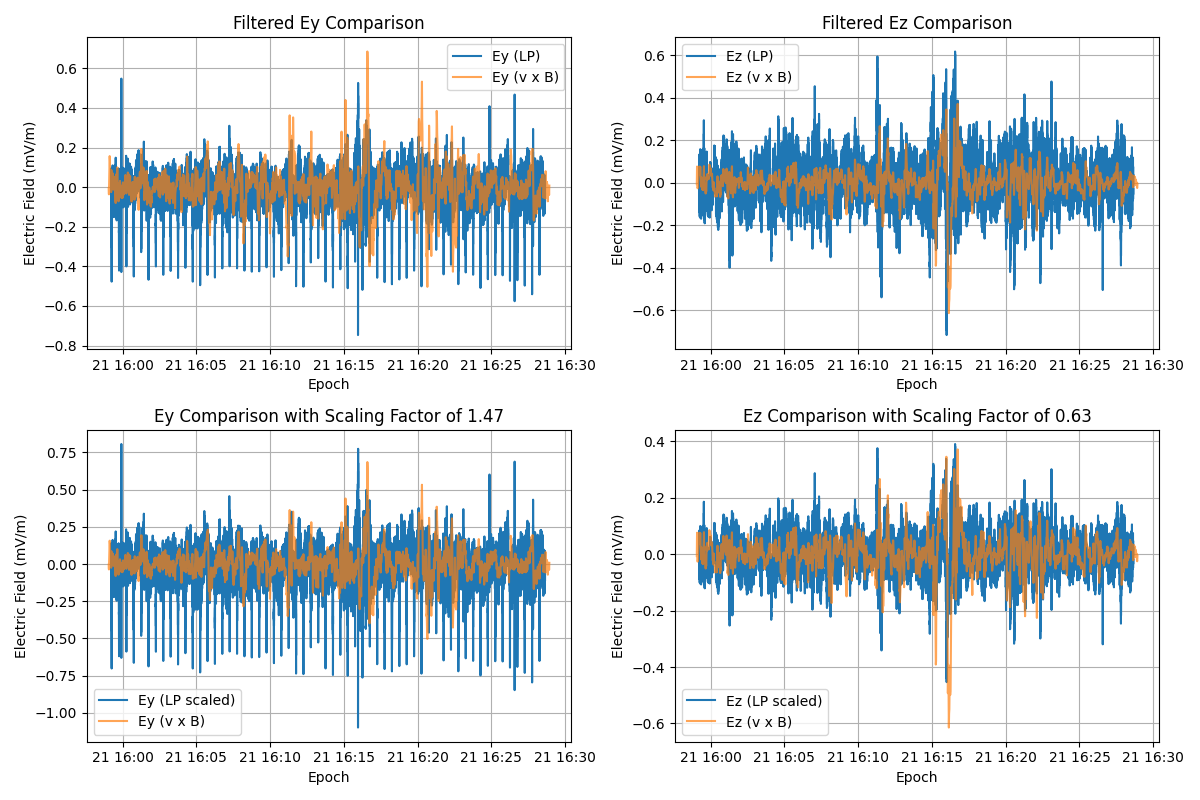

In [104]:
# Plot filtered E-field data

# Show the fourier spectral density of the original and filtered data

EyLP = Ey_sections[0][np.isfinite(Ey_sections[0])]
EzLP = Ez_sections[0][np.isfinite(Ez_sections[0])]

EyvCB_spectrum = np.abs(np.fft.fft(EyvCB_uniform))
EzvCB_spectrum = np.abs(np.fft.fft(EzvCB_uniform))
EyLP_spectrum = np.abs(np.fft.fft(EyLP))
EzLP_spectrum = np.abs(np.fft.fft(EzLP))
EyvCB_filtered_spectrum = np.abs(np.fft.fft(EyvCB_filtered))
EzvCB_filtered_spectrum = np.abs(np.fft.fft(EzvCB_filtered))
EyLP_filtered_spectrum = np.abs(np.fft.fft(Ey_filtered_sections[0]))
EzLP_filtered_spectrum = np.abs(np.fft.fft(Ez_filtered_sections[0]))

EyvCB_frequencies = np.fft.fftfreq(len(EyvCB_uniform))
EzvCB_frequencies = np.fft.fftfreq(len(EzvCB_uniform))
EyLP_frequencies = np.fft.fftfreq(len(EyLP), d=1e-3)
EzLP_frequencies = np.fft.fftfreq(len(EzLP), d=1e-3)
EyvCB_filtered_frequencies = np.fft.fftfreq(len(EyvCB_filtered))
EzvCB_filtered_frequencies = np.fft.fftfreq(len(EzvCB_filtered))
EyLP_filtered_frequencies = np.fft.fftfreq(len(Ey_filtered_sections[0]), d=1e-3)
EzLP_filtered_frequencies = np.fft.fftfreq(len(Ez_filtered_sections[0]), d=1e-3)

plt.figure(figsize=(12, 12))

# Taking only the positive frequencies for plotting
cutoff_idx = len(EyvCB_frequencies) // 2 - 1
cutoff_idx_filtered = len(EyvCB_filtered_frequencies) // 2 - 1
plt.subplot(2, 2, 1)
plt.scatter(EyvCB_frequencies[1:cutoff_idx], EyvCB_spectrum[1:cutoff_idx], label='Ey (-v x B) Spectrum')
plt.scatter(EyvCB_filtered_frequencies[1:cutoff_idx_filtered], EyvCB_filtered_spectrum[1:cutoff_idx_filtered], label='Ey (-v x B) Filtered Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Spectral Density')
plt.legend()
plt.grid()

cutoff_idx = len(EzvCB_frequencies) // 2 - 1
cutoff_idx_filtered = len(EzvCB_filtered_frequencies) // 2 - 1
plt.subplot(2, 2, 2)
plt.scatter(EzvCB_frequencies[1:cutoff_idx], EzvCB_spectrum[1:cutoff_idx], label='Ez (-v x B) Spectrum')
plt.scatter(EzvCB_filtered_frequencies[1:cutoff_idx_filtered], EzvCB_filtered_spectrum[1:cutoff_idx_filtered], label='Ez (-v x B) Filtered Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Spectral Density')
plt.legend()
plt.grid()

cutoff_idx = 20
cutoff_idx_filtered = 20
plt.subplot(2, 2, 3)
plt.scatter(EyLP_frequencies[1:cutoff_idx], EyLP_spectrum[1:cutoff_idx], label='Ey (LP) Spectrum')
plt.scatter(EyLP_filtered_frequencies[1:cutoff_idx_filtered], EyLP_filtered_spectrum[1:cutoff_idx_filtered], label='Ey (LP) Filtered Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Spectral Density')
plt.legend()
plt.grid()

cutoff_idx = 20
cutoff_idx_filtered = 20
plt.subplot(2, 2, 4)
plt.scatter(EzLP_frequencies[1:cutoff_idx], EzLP_spectrum[1:cutoff_idx], label='Ez (LP) Spectrum')
plt.scatter(EzLP_filtered_frequencies[1:cutoff_idx_filtered], EzLP_filtered_spectrum[1:cutoff_idx_filtered], label='Ez (LP) Filtered Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Spectral Density')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

factor_Ey = find_factor(Ey_filtered_full, EyvCB_filtered)
factor_Ez = find_factor(Ez_filtered_full, EzvCB_filtered)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(lp_epoch_filtered_full, Ey_filtered_full*1e3, label='Ey (LP)')
plt.plot(uniform_times_jmag, EyvCB_filtered*1e3, label='Ey (v x B)', alpha=0.7)
plt.title('Filtered Ey Comparison')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.grid()

plt.subplot(2, 2, 2)
plt.plot(lp_epoch_filtered_full, Ez_filtered_full*1e3, label='Ez (LP)')
plt.plot(uniform_times_jmag, EzvCB_filtered*1e3, label='Ez (v x B)', alpha=0.7)
plt.title('Filtered Ez Comparison')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.grid()

plt.subplot(2, 2, 3)
plt.plot(lp_epoch_filtered_full, Ey_filtered_full*1e3 * factor_Ey, label='Ey (LP scaled)')
plt.plot(uniform_times_jmag, EyvCB_filtered*1e3, label='Ey (v x B)', alpha=0.7)
plt.title(f'Ey Comparison with Scaling Factor of {factor_Ey:.2f}')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.grid()

plt.subplot(2, 2, 4)
plt.plot(lp_epoch_filtered_full, Ez_filtered_full*1e3 * factor_Ez, label='Ez (LP scaled)')
plt.plot(uniform_times_jmag, EzvCB_filtered*1e3, label='Ez (v x B)', alpha=0.7)
plt.title(f'Ez Comparison with Scaling Factor of {factor_Ez:.2f}')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.grid()

plt.tight_layout()
plt.show()

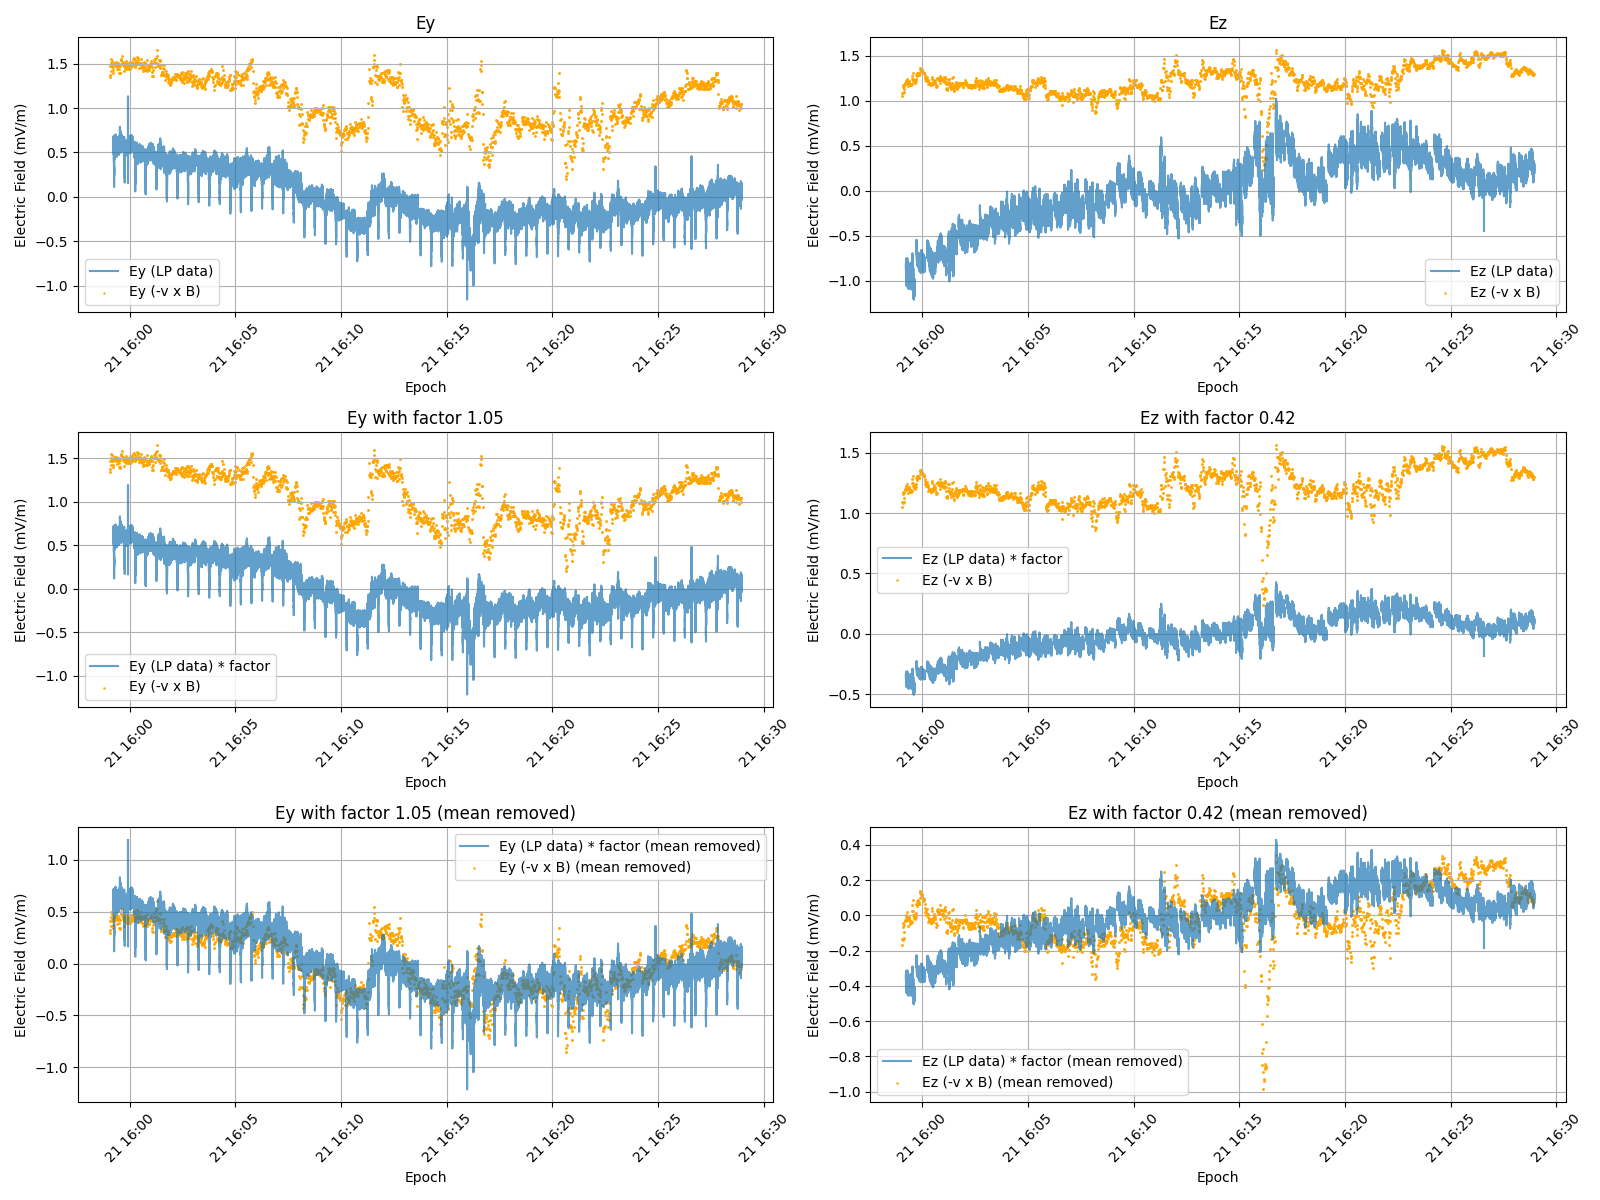

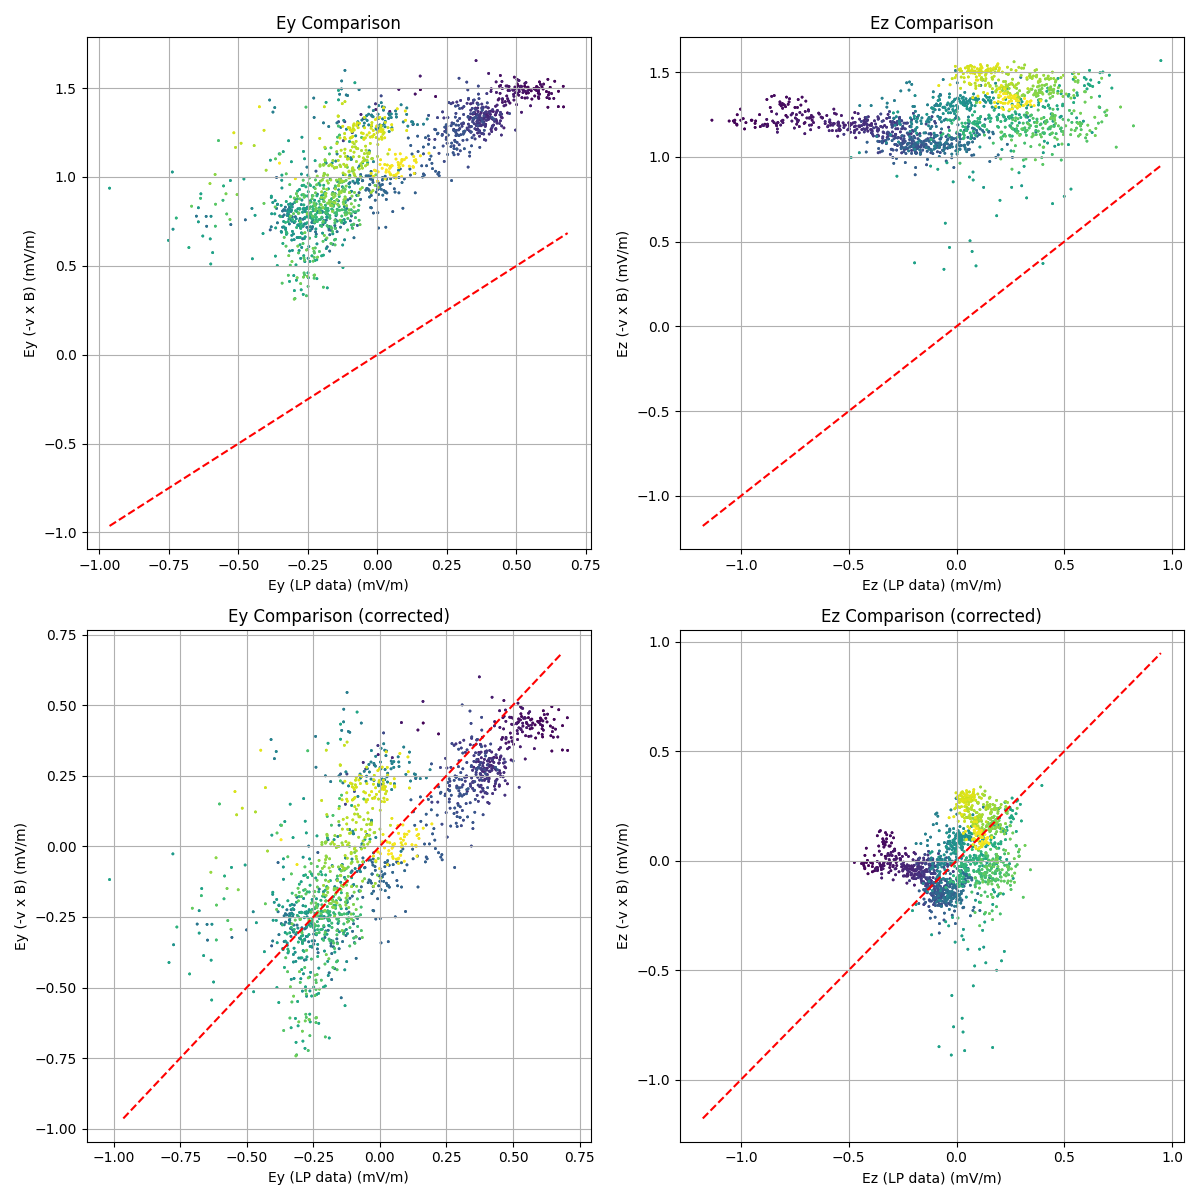

In [8]:
# Various correlation plots

# Convert datetime arrays to seconds since the start for interpolation
lp_epoch_seconds = np.array([(t - lp_epoch[0]).total_seconds() for t in lp_epoch])
jmag_epoch_seconds = np.array([(t - lp_epoch[0]).total_seconds() for t in jmag_epoch2])

# Resample the LP data to match the JMAG data length
Ey_model = interp1d(lp_epoch_seconds, Ey, bounds_error=False, kind='linear')
Ez_model = interp1d(lp_epoch_seconds, Ez, bounds_error=False, kind='linear')
Ex_model = interp1d(lp_epoch_seconds, Ex, bounds_error=False, kind='linear')
Ey_interp = Ey_model(jmag_epoch_seconds)
Ez_interp = Ez_model(jmag_epoch_seconds)
Ex_interp = Ex_model(jmag_epoch_seconds)

# Create a colormap based on time for the JMAG epoch
norm = Normalize(vmin=jmag_epoch_seconds.min(), vmax=jmag_epoch_seconds.max())
cmap = cm.viridis
colors = cmap(norm(jmag_epoch_seconds))

# Plot LP data and -v x B data, with a multiplicative factor minimizing the error between the two and removing the mean
Ey_factor = find_factor(Ey_interp, EyvCB)
Ez_factor = find_factor(Ez_interp, EzvCB)
EyvCB_mean = np.nanmean(EyvCB)
EzvCB_mean = np.nanmean(EzvCB)
EyvCB_0mean = EyvCB - EyvCB_mean
EzvCB_0mean = EzvCB - EzvCB_mean
Ey_mean = np.nanmean(Ey)
Ez_mean = np.nanmean(Ez)
Ey_0mean = Ey - Ey_mean
Ez_0mean = Ez - Ez_mean
Ey_interp_0mean = Ey_interp - Ey_mean
Ez_interp_0mean = Ez_interp - Ez_mean

plt.figure(figsize=(16, 12))

plt.subplot(3, 2, 1)
plt.plot(lp_epoch, Ey*1e3, label='Ey (LP data)', alpha=0.7)
plt.scatter(jmag_epoch2, EyvCB*1e3, label='Ey (-v x B)', alpha=0.7, s=1, color='orange')
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.title(f'Ey')
plt.xticks(rotation=45)
plt.legend()
plt.grid()

plt.subplot(3, 2, 2)
plt.plot(lp_epoch, Ez*1e3, label='Ez (LP data)', alpha=0.7)
plt.scatter(jmag_epoch2, EzvCB*1e3, label='Ez (-v x B)', alpha=0.7, s=1, color='orange')
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.title(f'Ez')
plt.xticks(rotation=45)
plt.legend()
plt.grid()

plt.subplot(3, 2, 3)
plt.plot(lp_epoch, Ey_factor*Ey*1e3, label='Ey (LP data) * factor', alpha=0.7)
plt.scatter(jmag_epoch2, EyvCB*1e3, label='Ey (-v x B)', alpha=0.7, s=1, color='orange')
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.title(f'Ey with factor {Ey_factor:.2f}')
plt.xticks(rotation=45)
plt.legend()
plt.grid()

plt.subplot(3, 2, 4)
plt.plot(lp_epoch, Ez_factor*Ez*1e3, label='Ez (LP data) * factor', alpha=0.7)
plt.scatter(jmag_epoch2, EzvCB*1e3, label='Ez (-v x B)', alpha=0.7, s=1, color='orange')
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.title(f'Ez with factor {Ez_factor:.2f}')
plt.xticks(rotation=45)
plt.legend()
plt.grid()

plt.subplot(3, 2, 5)
plt.plot(lp_epoch, Ey_factor*Ey_0mean*1e3, label='Ey (LP data) * factor (mean removed)', alpha=0.7)
plt.scatter(jmag_epoch2, EyvCB_0mean*1e3, label='Ey (-v x B) (mean removed)', alpha=0.7, s=1, color='orange')
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.title(f'Ey with factor {Ey_factor:.2f} (mean removed)')
plt.xticks(rotation=45)
plt.legend()
plt.grid()

plt.subplot(3, 2, 6)
plt.plot(lp_epoch, Ez_factor*Ez_0mean*1e3, label='Ez (LP data) * factor (mean removed)', alpha=0.7)
plt.scatter(jmag_epoch2, EzvCB_0mean*1e3, label='Ez (-v x B) (mean removed)', alpha=0.7, s=1, color='orange')
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.title(f'Ez with factor {Ez_factor:.2f} (mean removed)')
plt.xticks(rotation=45)
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# Plot correlation for corrected Ey and Ez against -v x B data with 0 mean
plt.figure(figsize=(12, 12))

plt.subplot(2, 2, 1)
plt.scatter(Ey_interp*1e3, EyvCB*1e3, s=1, color = colors)
plt.plot([np.nanmin(Ey_interp*1e3), np.nanmax(Ey_interp*1e3)], [np.nanmin(Ey_interp*1e3), np.nanmax(Ey_interp*1e3)], color='red', linestyle='--', label='y=x')
plt.xlabel('Ey (LP data) (mV/m)')
plt.ylabel('Ey (-v x B) (mV/m)')
plt.title('Ey Comparison')
plt.grid()

plt.subplot(2, 2, 2)
plt.scatter(Ez_interp*1e3, EzvCB*1e3, s=1, color = colors)
plt.plot([np.nanmin(Ez_interp*1e3), np.nanmax(Ez_interp*1e3)], [np.nanmin(Ez_interp*1e3), np.nanmax(Ez_interp*1e3)], color='red', linestyle='--', label='y=x')
plt.xlabel('Ez (LP data) (mV/m)')
plt.ylabel('Ez (-v x B) (mV/m)')
plt.title('Ez Comparison')
plt.grid()

plt.subplot(2, 2, 3)
plt.scatter(Ey_factor*Ey_interp_0mean*1e3, EyvCB_0mean*1e3, s=1, color=colors)
plt.plot([np.nanmin(Ey_interp_0mean*1e3), np.nanmax(Ey_interp_0mean*1e3)], [np.nanmin(Ey_interp_0mean*1e3), np.nanmax(Ey_interp_0mean*1e3)], color='red', linestyle='--', label='y=x')
plt.xlabel('Ey (LP data) (mV/m)')
plt.ylabel('Ey (-v x B) (mV/m)')
plt.title('Ey Comparison (corrected)')
plt.grid()

plt.subplot(2, 2, 4)
plt.scatter(Ez_factor*Ez_interp_0mean*1e3, EzvCB_0mean*1e3, s=1, color=colors)
plt.plot([np.nanmin(Ez_interp_0mean*1e3), np.nanmax(Ez_interp_0mean*1e3)], [np.nanmin(Ez_interp_0mean*1e3), np.nanmax(Ez_interp_0mean*1e3)], color='red', linestyle='--', label='y=x')
plt.xlabel('Ez (LP data) (mV/m)')
plt.ylabel('Ez (-v x B) (mV/m)')
plt.title('Ez Comparison (corrected)')
plt.grid()

plt.tight_layout()
plt.show()

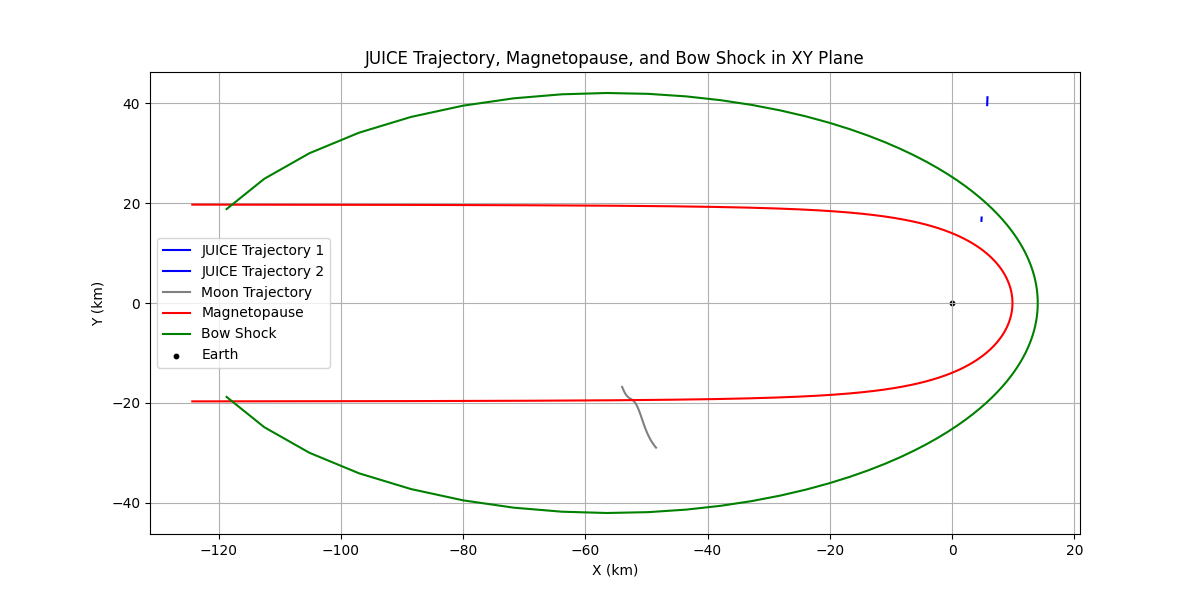

In [ ]:
# Get the position of JUICE on 2024/08/21 and compare it to the positions of the magnetopause and bow shock

pressure_cdf = cdflib.CDF('../DATA/wi_k0s_swe_20240821000335_20240821235902_cdaweb.cdf')

P_sw = pressure_cdf.varget('Pressure')
P_sw[abs(P_sw) > 100] = np.nan
P_sw = np.nanmean(P_sw)
R_E = 6371  # Earth radius in km

# Load the necessary SPICE kernels
spice.furnsh("../SPICE/JUICE/kernels/mk/juice_ops.tm")
spice.furnsh("../SPICE/gsm_frame.tf")

start_date_moon = dt.datetime(2024, 8, 21, 0, 0, 0)
end_date_moon = dt.datetime(2024, 8, 22, 0, 0, 0)
et_start_moon = spice.str2et(start_date_moon.strftime("%Y-%m-%dT%H:%M:%S"))
et_end_moon = spice.str2et(end_date_moon.strftime("%Y-%m-%dT%H:%M:%S"))
time_interval_moon = np.linspace(et_start_moon, et_end_moon, num=100)
pos_moon, _ = spice.spkpos("MOON", time_interval_moon, "GSM", "NONE", "EARTH")

start_date_juice1 = dt.datetime(2024, 8, 21, 4, 25, 0)
end_date_juice1 = dt.datetime(2024, 8, 21, 4, 45, 0)
et_start_juice1 = spice.str2et(start_date_juice1.strftime("%Y-%m-%dT%H:%M:%S"))
et_end_juice1 = spice.str2et(end_date_juice1.strftime("%Y-%m-%dT%H:%M:%S"))
time_interval_juice1 = np.linspace(et_start_juice1, et_end_juice1, num=100)
pos_juice1, _ = spice.spkpos("JUICE", time_interval_juice1, "GSM", "NONE", "EARTH")

start_date_juice2 = dt.datetime(2024, 8, 21, 15, 55, 0)
end_date_juice2 = dt.datetime(2024, 8, 21, 16, 30, 0)
et_start_juice2 = spice.str2et(start_date_juice2.strftime("%Y-%m-%dT%H:%M:%S"))
et_end_juice2 = spice.str2et(end_date_juice2.strftime("%Y-%m-%dT%H:%M:%S"))
time_interval_juice2 = np.linspace(et_start_juice2, et_end_juice2, num=100)
pos_juice2, _ = spice.spkpos("JUICE", time_interval_juice2, "GSM", "NONE", "EARTH")

theta = np.linspace(-19*np.pi/20, 19*np.pi/20, 100)

# Calculate the magnetopause and bow shock positions
r_mp = magnetopause(P_sw, theta)
x_mp = R_E * r_mp * np.cos(theta)
y_mp = R_E * r_mp * np.sin(theta)

# Calculate bow shock
r_bs = bow_shock(P_sw, theta)
x_bs = R_E * r_bs * np.cos(theta)
y_bs = R_E * r_bs * np.sin(theta)

# Plot the JUICE trajectory in the XY plane as well as the magnetopause and bow shock
plt.figure(figsize=(12, 6))
plt.plot(pos_juice1[:, 0]/R_E, pos_juice1[:, 1]/R_E, label='JUICE Trajectory 1', color='blue')
plt.plot(pos_juice2[:, 0]/R_E, pos_juice2[:, 1]/R_E, label='JUICE Trajectory 2', color='blue')	
plt.plot(pos_moon[:, 0]/R_E, pos_moon[:, 1]/R_E, label='Moon Trajectory', color='gray')
plt.plot(x_mp/R_E, y_mp/R_E, label='Magnetopause', color='red')
plt.plot(x_bs/R_E, y_bs/R_E, label='Bow Shock', color='green')
plt.scatter(0, 0, color='black', label='Earth', s=10)  # Earth at the origin
plt.title(f'JUICE Trajectory, Magnetopause, and Bow Shock in XY Plane')
plt.xlabel('X (Earth radii)')
plt.ylabel('Y (Earth radii)')
plt.legend()
plt.grid()
plt.show()

# Unload SPICE kernels
spice.kclear()

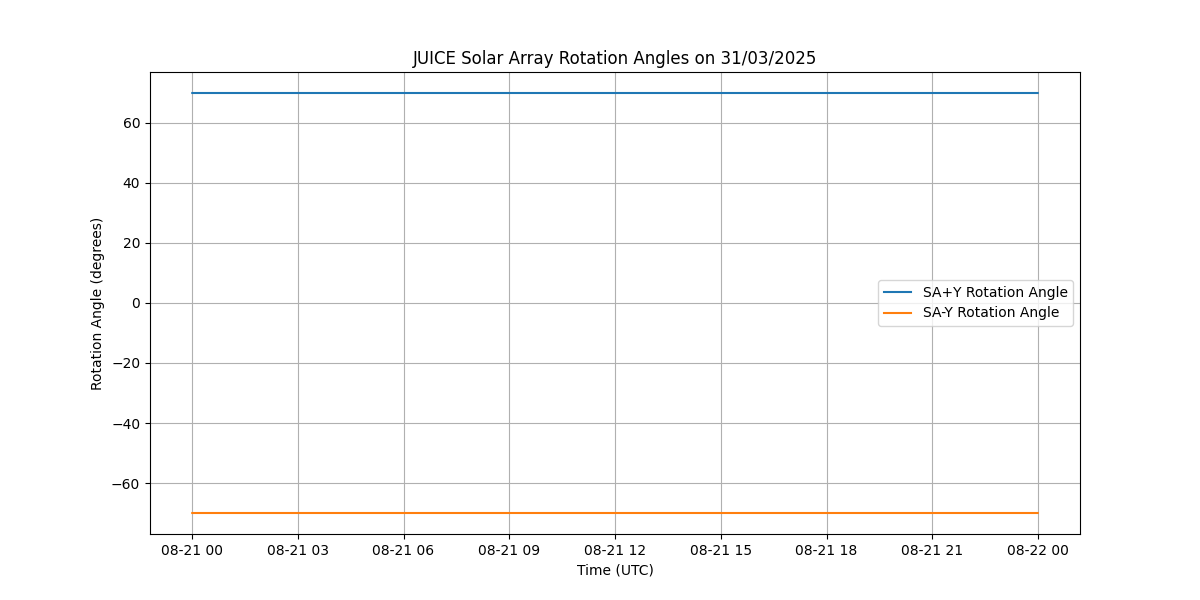

In [10]:
# Looking at the position of the solar arrays

# Load the SPICE kernels for JUICE
spice.furnsh("../SPICE/JUICE/kernels/mk/juice_ops.tm")

# Construct the time range for the position data
start_time = dt.datetime(2024, 8, 21, 0, 0, 0)
end_time = dt.datetime(2024, 8, 21, 23, 59, 59)

# Convert the start and end times to ephemeris time
start_et = spice.str2et(start_time.strftime("%Y-%m-%dT%H:%M:%S"))
end_et = spice.str2et(end_time.strftime("%Y-%m-%dT%H:%M:%S"))
time_range = np.arange(start_et, end_et, 60)  # 1-minute intervals

rotation_angles_plus = []
rotation_angles_minus = []

for et in time_range:
    matrix_plus = spice.pxform("JUICE_SA+Y_ZERO", "JUICE_SA+Y", et)
    angle_plus = np.arctan2(matrix_plus[0, 2], matrix_plus[0, 0]) * 180 / np.pi
    rotation_angles_plus.append(angle_plus)

    matrix_minus = spice.pxform("JUICE_SA-Y_ZERO", "JUICE_SA-Y", et)
    angle_minus = np.arctan2(matrix_minus[0, 2], matrix_minus[0, 0]) * 180 / np.pi
    rotation_angles_minus.append(angle_minus)

# Convert ephemeris time to datetime for plotting
time_range_dt = [dt.datetime.utcfromtimestamp(et - spice.str2et("1970-01-01T00:00:00")) for et in time_range]

plt.figure(figsize=(12, 6))
plt.plot(time_range_dt, rotation_angles_plus, label='SA+Y Rotation Angle')
plt.plot(time_range_dt, rotation_angles_minus, label='SA-Y Rotation Angle')
plt.xlabel('Time (UTC)')
plt.ylabel('Rotation Angle (degrees)')
plt.title('JUICE Solar Array Rotation Angles on 31/03/2025')
plt.legend()
plt.grid()
plt.show()

spice.kclear()  # Unload the SPICE kernels